# Single closed loop inference for freeflyer

In [1]:
import os
import sys
from pathlib import Path
root_folder = Path.cwd().parent

# Add to sys.path
sys.path.append(str(root_folder))

import time
import numpy as np
import numpy.linalg as la
import itertools
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.lines import Line2D

import itertools
from multiprocessing import Pool, set_start_method
from tqdm import tqdm

# /src/
import optimization.ff_scenario as ff
import decision_transformer.manage as DT_manager
from dynamics.freeflyer import FreeflyerModel, ocp_no_obstacle_avoidance, ocp_obstacle_avoidance, ocp_obstacle_avoidance_feasibility_ST, compute_constraint_to_go, sample_init_target
from optimization.ff_scenario import n_time_rpod, N_STATE, N_ACTION, obs, iter_max_SCP, robot_radius, safety_margin, table
from decision_transformer.adapter import FrozenTextAdapter
from dataset_generation.dataset_pargen import load_behavior_texts, get_behavior_text_batch, get_behavior_text, build_goal_regions_3x3_xgt12, sample_time_horizon_from_last_4_chunks 

device = DT_manager.device
print(f"Using device: {device}")
set_start_method('spawn')

/home/arpit/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/arpit/miniforge3/envs/ART/lib/python3.10/site-packages/transformers/utils/generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/home/arpit/miniforge3/envs/ART/lib/python3.10/site-packages/transformers/utils/generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Using device: cuda


In [3]:
def _shrink_interval(lo, hi, margin):
    lo2 = lo + margin
    hi2 = hi - margin
    if hi2 <= lo2:
        return None
    return lo2, hi2


def is_goal_clear_of_obstacles(p_xy: np.ndarray) -> bool:
    """
    Reject if goal lies within any inflated obstacle:
      inflated_radius = (obs_radius + robot_radius) * safety_margin
    """
    c_all = np.asarray(ff.obs["position"], dtype=float)  # (3,2)
    r_all = np.asarray(ff.obs["radius"], dtype=float)    # (3,)
    robot_r = float(ff.robot_radius)
    gamma = float(ff.safety_margin)

    inflated = (r_all + robot_r) * gamma
    d = np.linalg.norm(p_xy - c_all, axis=1)
    return bool(np.all(d >= inflated))

def sample_goal_in_region(
    rng,
    region,
    table_boundary_buffer=0.05,
    region_boundary_buffer=0.15,
    max_tries=512,
):
    """
    Sample a goal point uniformly in a region but avoid:
      - table edges (table_boundary_buffer)
      - region grid lines (region_boundary_buffer)
      - obstacles (inflated)
    """
    table_lo = np.asarray(ff.table["xy_low"], dtype=float)
    table_hi = np.asarray(ff.table["xy_up"], dtype=float)

    rx_lo, rx_hi, ry_lo, ry_hi = region

    # Table boundary buffer
    xlo = max(rx_lo, table_lo[0] + table_boundary_buffer)
    xhi = min(rx_hi, table_hi[0] - table_boundary_buffer)
    ylo = max(ry_lo, table_lo[1] + table_boundary_buffer)
    yhi = min(ry_hi, table_hi[1] - table_boundary_buffer)

    # Region boundary buffer (stay away from internal grid lines)
    xshr = _shrink_interval(xlo, xhi, region_boundary_buffer)
    yshr = _shrink_interval(ylo, yhi, region_boundary_buffer)
    if xshr is None or yshr is None:
        raise ValueError("Region too small after buffers; reduce buffers or adjust x_min/grid.")

    xlo, xhi = xshr
    ylo, yhi = yshr

    for _ in range(max_tries):
        p = np.array([rng.uniform(xlo, xhi), rng.uniform(ylo, yhi)], dtype=float)
        if is_goal_clear_of_obstacles(p):
            return p

    raise RuntimeError("Failed to sample a collision-free goal in region after many tries.")


In [4]:
model_version_ctg = 'v_05'  # v_02: Lang_ctg model does not take goal as input (text + constraint + state + action only)
dataset_version = 'v02'

import_config = DT_manager.transformer_import_config(model_version_ctg)
ctg_condition = import_config["ctg_condition"]
timestep_norm = import_config["timestep_norm"]
dataset_to_use = import_config["dataset_to_use"] 


# Get the datasets and loaders from the torch data
datasets, dataloaders = DT_manager.get_train_val_test_data( ctg_condition=ctg_condition, timestep_norm=timestep_norm, dataset_to_use=dataset_to_use, dataset_version=dataset_version, max_samples = 80000)
train_loader, eval_loader, test_loader = dataloaders

# Get both ART models
model_ctg = DT_manager.get_DT_model(model_version_ctg, train_loader, eval_loader, ctg_condition = True)

# load the text encoders for each models (and its weight)  
MODEL = os.getenv("FTA_MODEL", "distilbert-base-uncased")
text_encoder_ctg = FrozenTextAdapter(model_name=MODEL, out_dim=model_ctg.hidden_size, output_mode="tokens").to(device).eval()
text_encoder_ctg.load_adapter(root_folder / "decision_transformer" / "saved_files" / "checkpoints" / f"{model_version_ctg}" / "text_adapter.pth") 


CTG condition set to:  True
Data is loaded but not shuffled yet!

Data shuffled and combined from both SCP and CVX datasets.

torch.Size([80000, 100, 6])
GPT size: 11.1M parameters


/home/arpit/miniforge3/envs/ART/lib/python3.10/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


# Helper Func

In [15]:
# FreeFlyerModel
ff_model = FreeflyerModel()
def _plot_environment(ax):
    # Table
    ax.add_patch(
        Rectangle(
            (table['xy_low'][0], table['xy_low'][1]),
            table['xy_up'][0] - table['xy_low'][0],
            table['xy_up'][1] - table['xy_low'][1],
            fc=(0.5, 0.5, 0.5, 0.15),
            ec='k',
            # label='table',
            label=None,
            zorder=2.5,
        )
    )

    # Obstacles + inflated robot radius
    for n in range(obs['radius'].shape[0]):
        lab1 = 'Obstacle'
        lab3 = 'L/R Body' if n == 0 else None
        # lab2 = 'robot radius' if n == 0 else None
        lab2 =  None
        if n == 1:
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n],
                    fc='r',
                    ec='none',
                    label=lab1,
                    zorder=2.6,
                )
            )
            # ax.add_patch(
            #     Circle(
            #         obs['position'][n, :],
            #         obs['radius'][n] + robot_radius,
            #         fc='grey',
            #         alpha=0.2,
            #         ec='none',
            #         label=lab2,
            #         zorder=2.6,
            #     )
            # )
        else:
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n],
                    fc='g',
                    ec='none',
                    label=lab3,
                    zorder=2.6,
                )
            )
            # ax.add_patch(
            #     Circle(
            #         obs['position'][n, :],
            #         obs['radius'][n] + robot_radius,
            #         fc='grey',
            #         alpha=0.2,
            #         ec='none',
            #         label=lab2,
            #         zorder=2.6,
            #     )
            # )

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(table['xy_low'][0], table['xy_up'][0])
    ax.set_ylim(table['xy_low'][1], table['xy_up'][1])

# pad the traj to always be shape [6,101] and [3, 100]

def build_goal_regions_3x3_(x_min=1.2, ncols=3, nrows=3):
    """3×3 grid for x > x_min. Returns (regions, xs, ys) as in test_data_generation."""
    table_lo = np.asarray(ff.table["xy_low"], dtype=float)
    table_hi = np.asarray(ff.table["xy_up"], dtype=float)
    xlo = max(float(x_min), float(table_lo[0]))
    xhi = float(table_hi[0])
    ylo = float(table_lo[1])
    yhi = float(table_hi[1])
    xs = np.linspace(xlo, xhi, ncols + 1)
    ys = np.linspace(ylo, yhi, nrows + 1)
    regions = []
    for r in range(nrows):
        for c in range(ncols):
            regions.append((xs[c], xs[c + 1], ys[r], ys[r + 1]))
    return regions, xs, ys

def plot_9_region_grid(ax, x_min=1.2, xs=None, ys=None, annotate=False):
    """Draw 3×3 grid lines on x > x_min (spatial discretization for behavior_mode)."""
    if xs is None or ys is None:
        _, xs, ys = build_goal_regions_3x3_xgt12(x_min=x_min)
    x0, x1 = xs[0], xs[-1]
    y0, y1 = ys[0], ys[-1]
    for x in xs:
        ax.plot([x, x], [y0, y1], color="k", linewidth=0.8, alpha=0.6)
    for y in ys:
        ax.plot([x0, x1], [y, y], color="k", linewidth=0.8, alpha=0.6)
    if annotate:
        # Row-major with low y first — matches dataset_pargen / gpt_prompting REGION_INFO ids
        region_labels = [
            "left_bottom", "center_bottom", "right_bottom",
            "left_mid", "center_mid", "right_mid",
            "left_top", "center_top", "right_top",
        ]
        rid = 0
        for r in range(len(ys) - 1):
            for c in range(len(xs) - 1):
                cx = 0.5 * (xs[c] + xs[c + 1])
                cy = 0.5 * (ys[r] + ys[r + 1])
                ax.text(
                    cx,
                    cy,
                    region_labels[rid],
                    ha="center",
                    va="center",
                    fontsize=10.5,
                    clip_on=True,
                )
                rid += 1
                
def pad_traj_to_full(states, actions_G, n_time_rpod):
    """
    states:  (6, k_T+1)
    actions: (3, k_T)
    returns: states (6, n_time_rpod+1), actions (3, n_time_rpod)
    """
    cur_S = states.shape[1]   # k_T+1
    cur_A = actions_G.shape[1]  # k_T
    need_S = (n_time_rpod + 1) - cur_S
    need_A = n_time_rpod - cur_A
    if need_S > 0:
        states = np.hstack([states, np.repeat(states[:, -1][:, None], need_S, axis=1)])
    if need_A > 0:
        actions_G = np.hstack([actions_G, np.zeros((actions_G.shape[0], need_A))])
    return states, actions_G

In [6]:
'''
Test samples for inference (27 behavior modes).
  behavior_i 0..26: region_id = bm%9, time_id = bm//9, k_T in {60,80,100}.
  Goal sampled in 3×3 region (x>1.2); no waypoint.
'''
state_init = np.array([0.5, 2.1, 0.0, 0.0, 0.0, 0.0])

# 27-mode: behavior_i 0..26 → region_id = bm%9, time_id = bm//9, k_T in {60,80,100}
current_idx = 90
seed = 7 + current_idx
rng = np.random.default_rng(seed)
behavior_i = 2  # 0..26
region_id = behavior_i % 9
time_id = behavior_i // 9
k_T = [60, 80, 100][time_id]
wp = None
regions = build_goal_regions_3x3_xgt12(x_min=1.2, ncols=3, nrows=3)
goal_xy = sample_goal_in_region(rng, regions[region_id])
state_final = np.zeros(6, dtype=float)
state_final[0:2] = goal_xy

# command_mapping = load_behavior_texts(root_folder / "dataset" / "master_file_old.json")
# command_mapping = load_behavior_texts(root_folder / "dataset" / "master_file.json")
command_mapping = load_behavior_texts(root_folder / "dataset" / "master_file_new.json")
command_id = int(rng.integers(0, 100))
text_command = get_behavior_text(command_mapping, behavior_i, command_id)


print(text_command)
text_command = "Fly a moderate transit toward the lower right sector band through the free corridor."
text_command = "Aprroach to right-bottom in 32-40 seconds."
# text_command = "Approach upper left region and then move to lower left region."


print("text command", text_command)
print(f'behavior_i={behavior_i} region={region_id} time_id={time_id} k_T={k_T} goal_xy={goal_xy}')
##################################

test_sample = test_loader.dataset.getix(current_idx)
data_stats = test_loader.dataset.data_stats

(states_i, actions_i, rtgs_i, ctgs_i, goal_i, timesteps_i, attention_mask_i, dt, time_sec, ix, behavior_i_t, command_id_i_t) = test_sample
print(states_i[0, 0, :])
test_sample[0][0,:,:] = (torch.tensor(np.repeat(state_init[None,:], n_time_rpod, axis=0)) - data_stats['states_mean'])/(data_stats['states_std'] + 1e-6)
test_sample[1][0,:,:] = torch.zeros((n_time_rpod, N_ACTION))
test_sample[2][0,:,0] = torch.zeros((n_time_rpod,))
test_sample[3][:,0] = torch.zeros((n_time_rpod,))

# Set goal to our sampled state_final (27-mode) and normalize.
# For v_02 the model does not receive goal as input; goal_i stays in the tuple for API compatibility,
# and goal_xy/state_final are used for evaluation (e.g. "Reached goal @ t=...") and plotting.
goal_mean = data_stats['goal_mean']; goal_std = data_stats['goal_std']
if goal_mean.dim() == 2:
    goal_mean, goal_std = goal_mean[0,:], goal_std[0,:]
goal_norm = (torch.tensor(state_final, dtype=torch.float32) - goal_mean) / (goal_std + 1e-6)
goal_i[0,:,:] = goal_norm.unsqueeze(0).expand(goal_i.shape[1], -1)

# Repack test_sample
test_sample = (states_i, actions_i, rtgs_i, ctgs_i, goal_i, timesteps_i, attention_mask_i, dt, time_sec, ix, behavior_i_t, command_id_i_t)
print(test_sample[0][0, 0, :])

The robot swiftly executes a KOZ-compliant trajectory to the lower-right, ensuring precise standoff throughout.
text command Aprroach to right-bottom in 32-40 seconds.
behavior_i=2 region=2 time_id=0 k_T=60 goal_xy=[3.16428059 0.40895043]
tensor([-1.0234e+00, -1.0992e+00, -2.5379e+00, -1.0852e+00, -1.4787e-03,
         4.7148e-04])
tensor([-7.2210e-01,  1.5740e+00, -7.1345e-04, -1.0852e+00, -1.4787e-03,
         4.7148e-04])


# Save the datastats file in dataset/torch/v01/data_state.npz

In [ ]:
# save the data_stats for later use
# data_stats_path = root_folder / "dataset" / "torch" / f"{dataset_version}" / f"data_stats.npz"
# np.savez(data_stats_path, data_stats=data_stats)

# Load the inference

In [7]:


runtime0_cvx = time.time()
traj_cvx, _, _, feas_cvx = ocp_no_obstacle_avoidance(ff_model, state_init, state_final, n_time_override=k_T, waypoint=wp)
runtime1_cvx = time.time()
runtime_cvx = runtime1_cvx - runtime0_cvx

# If CVX solver failed (infeasible), stop and ask for a new initial condition
cvx_ok = (
    traj_cvx is not None
    and str(feas_cvx).strip().lower() == "optimal"
    and traj_cvx.get("states") is not None
    and traj_cvx.get("actions_G") is not None
)
if not cvx_ok:
    raise RuntimeError(
        "CVX solver failed (infeasible or returned None). "
        "Re-run the 'Test sample' cell above to sample a new initial condition and goal (e.g. change current_idx or behavior_i), then run this cell again."
    )

states_cvx, actions_cvx = traj_cvx["states"], traj_cvx["actions_G"]

print('CVX cost:', np.sum(la.norm(actions_cvx, ord=1, axis=0)))
print('CVX runtime:', runtime_cvx)
states_cvx_full, actions_cvx_full = pad_traj_to_full(states_cvx, actions_cvx, n_time_rpod)

states_ws_cvx = states_cvx # set warm start
actions_ws_cvx = actions_cvx # set warm start
# Evaluate Constraint Violation
ctgs_cvx = compute_constraint_to_go(states_ws_cvx.T, obs['position'], (obs['radius'] + robot_radius)*safety_margin)
ctgs0_cvx = ctgs_cvx[0,0]

# Solve SCP
runtime0_scp_cvx = time.time()
traj_scp_cvx, J_vect_scp_cvx, iter_scp_cvx, feas_scp_cvx = ocp_obstacle_avoidance_feasibility_ST(ff_model, states_ws_cvx, actions_ws_cvx, state_init, w_tracking=1.0)
runtime1_scp_cvx = time.time()
runtime_scp_cvx = runtime1_scp_cvx - runtime0_scp_cvx

states_scp_full, actions_scp_full = pad_traj_to_full(traj_scp_cvx['states'], traj_scp_cvx['actions_G'], n_time_rpod)
print('SCP cost:', np.sum(la.norm(actions_scp_full, ord=1, axis=0)))
print('SCP runtime:', runtime_scp_cvx, iter_scp_cvx)



CVX cost: 0.4573841027511289
CVX runtime: 0.6582224369049072
SCP cost: 0.8028078165090495
SCP runtime: 1.271796464920044 2


In [8]:

DT_ctg_trajectory, runtime_DT_ctg = DT_manager.torch_model_inference_dyn(model_ctg, test_loader, test_sample, text_encoder_ctg, command_mapping, ctg_condition=True, text_command=text_command)
# DT_ctg_trajectory, runtime_DT_ctg = DT_manager.torch_model_inference_dyn(model_ctg, test_loader, test_sample, text_encoder_ctg, command_mapping, ctg_condition=True, text_command=None)
states_ws_DT_ctg = np.append(DT_ctg_trajectory['xypsi_dyn'], (DT_ctg_trajectory['xypsi_dyn'][:,-1] + ff_model.B_imp @ DT_ctg_trajectory['dv_dyn'][:, -1]).reshape((6,1)), 1)# set warm start
actions_ws_DT_ctg = DT_ctg_trajectory['dv_dyn'] # set warm start
print('ART cost:', np.sum(la.norm(actions_ws_DT_ctg, ord=1, axis=0)))
print('ART runtime:', runtime_DT_ctg)

# Evaluate Constraint Violation
ctgs_DT_ctg = compute_constraint_to_go(states_ws_DT_ctg.T, obs['position'], (obs['radius'] + robot_radius)*safety_margin)
ctgs0_DT_ctg = ctgs_DT_ctg[0,0]

# Solve SCP
runtime0_scp_DT_ctg = time.time()
traj_scp_DT_ctg, J_vect_scp_DT_ctg, iter_scp_DT_ctg, feas_scp_DT_ctg = ocp_obstacle_avoidance_feasibility_ST(ff_model, states_ws_DT_ctg, actions_ws_DT_ctg, state_init)
runtime1_scp_DT_ctg = time.time()
runtime_scp_DT_ctg = runtime1_scp_DT_ctg - runtime0_scp_DT_ctg  

states_scp_DT_ctg = traj_scp_DT_ctg['states']
actions_scp_DT_ctg = traj_scp_DT_ctg['actions_G'] 

print('SCP cost:', np.sum(la.norm(actions_scp_DT_ctg, ord=1, axis=0)))
print('SCP time and iter:',runtime_scp_DT_ctg ,iter_scp_DT_ctg)

# Evaluate Constraint Violation
ctgs_DT_scp_ctg = compute_constraint_to_go(states_scp_DT_ctg.T, obs['position'], (obs['radius'] + robot_radius)*safety_margin)
ctgs0_DT_scp_ctg = ctgs_DT_scp_ctg[0,0]


ART cost: 0.32020444
ART runtime: 0.421478271484375
SCP cost: 0.3641334506144287
SCP time and iter: 2.230489492416382 2


2 2


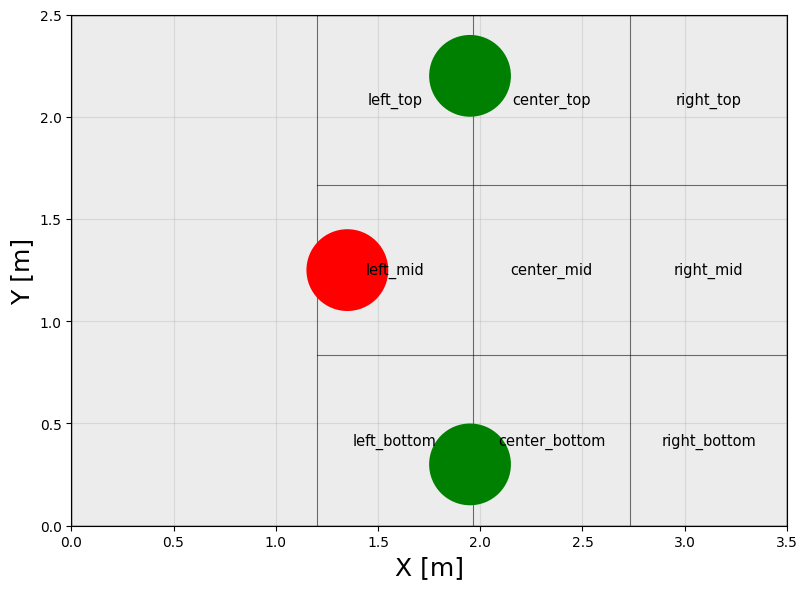

In [19]:

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

regions, grid_xs, grid_ys = build_goal_regions_3x3_(x_min=1.2, ncols=3, nrows=3)
def plot_time_colored_line(ax, xs, ys, cmap='plasma', label=None):

    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap)
    lc.set_array(np.arange(len(xs)))   # color = time index
    lc.set_linewidth(3.0)
    
    ax.add_collection(lc)
    return lc

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()
_plot_environment(ax)
plot_9_region_grid(ax, x_min=1.2, xs=grid_xs, ys=grid_ys, annotate=True)

mid_color = plt.get_cmap('plasma')(0.5)   # 0.5 = midpoint of colormap
sages_handle = Line2D(
    [0], [0],
    color=mid_color,
    linewidth=3,
    label='SAGES'
)

# ax.plot(
#     states_scp_full[0, :], states_scp_full[1, :],
#     linestyle='-', color='darkgreen', linewidth=2.0,
#     label='CVX-SCP', zorder=4
# )

# ax.plot(
#     states_ws_cvx[0, :], states_ws_cvx[1, :],
#     linestyle=(0, (10, 10)), color='mediumseagreen', linewidth=1.,
#     label='CVX', zorder=4
# )

# ax.plot(
#     states_ws_DT_ctg[0, :], states_ws_DT_ctg[1, :],
#     linestyle=(0, (6, 10)), color='purple', linewidth=1.5,
#     label='SAGES-WS', zorder=4
# )


# Example usage:
# Time-colored SCP trajectory
# lc = plot_time_colored_line(
#     ax,
#     states_scp_DT_ctg[0,:],
#     states_scp_DT_ctg[1,:],
# )
# cb = fig.colorbar(lc, ax=ax, shrink=0.7)
# cb.set_label("Time Step", fontsize = 15)

# Annotate goal reach time: first time (x,y) enters the grid region for this behavior
region_id = behavior_i % 9
print(behavior_i, region_id)
x_lo, x_hi, y_lo, y_hi = regions[region_id]
in_region = ((states_scp_DT_ctg[0, :] >= x_lo) & (states_scp_DT_ctg[0, :] <= x_hi) & (states_scp_DT_ctg[1, :] >= y_lo) & (states_scp_DT_ctg[1, :] <= y_hi))
t_goal = int(np.argmax(in_region)) if np.any(in_region) else (states_scp_DT_ctg.shape[1] - 1)
offset = np.array([-1.2, -0.2])   # tune depending on scale
gx, gy = (x_lo + x_hi) / 2, (y_lo + y_hi) / 2   # center of goal region
# ax.annotate(f"Entered region {region_id} @ t={t_goal}",
#             xy=(gx, gy),
#             xytext=(gx + offset[0], gy + offset[1]),
#             fontsize=15,
#             arrowprops=dict(arrowstyle="->", lw=1.8))

# ax.scatter(state_init[0], state_init[1], s=50, marker='o', c='red', label='state init', zorder=5)
# ax.scatter(state_final[0], state_final[1], s=50, marker='*', c='orange', label='state final', zorder=5)


# Formatting
ax.set_aspect('equal')
ax.set_xlabel('X [m]', fontsize=18)
ax.set_ylabel('Y [m]', fontsize=18)
ax.grid(True, alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
handles.append(sages_handle)
labels.append('SAGES')

# ax.legend(loc='best', fontsize=18)
# ax.legend(handles, labels,
#            loc='lower center',
#            ncol=len(labels)//2,
#            bbox_to_anchor=(0.5, -0.30),
#            fontsize=14)
plt.tight_layout()
plt.savefig('test_ff_inference.png', dpi= 600)
plt.show()



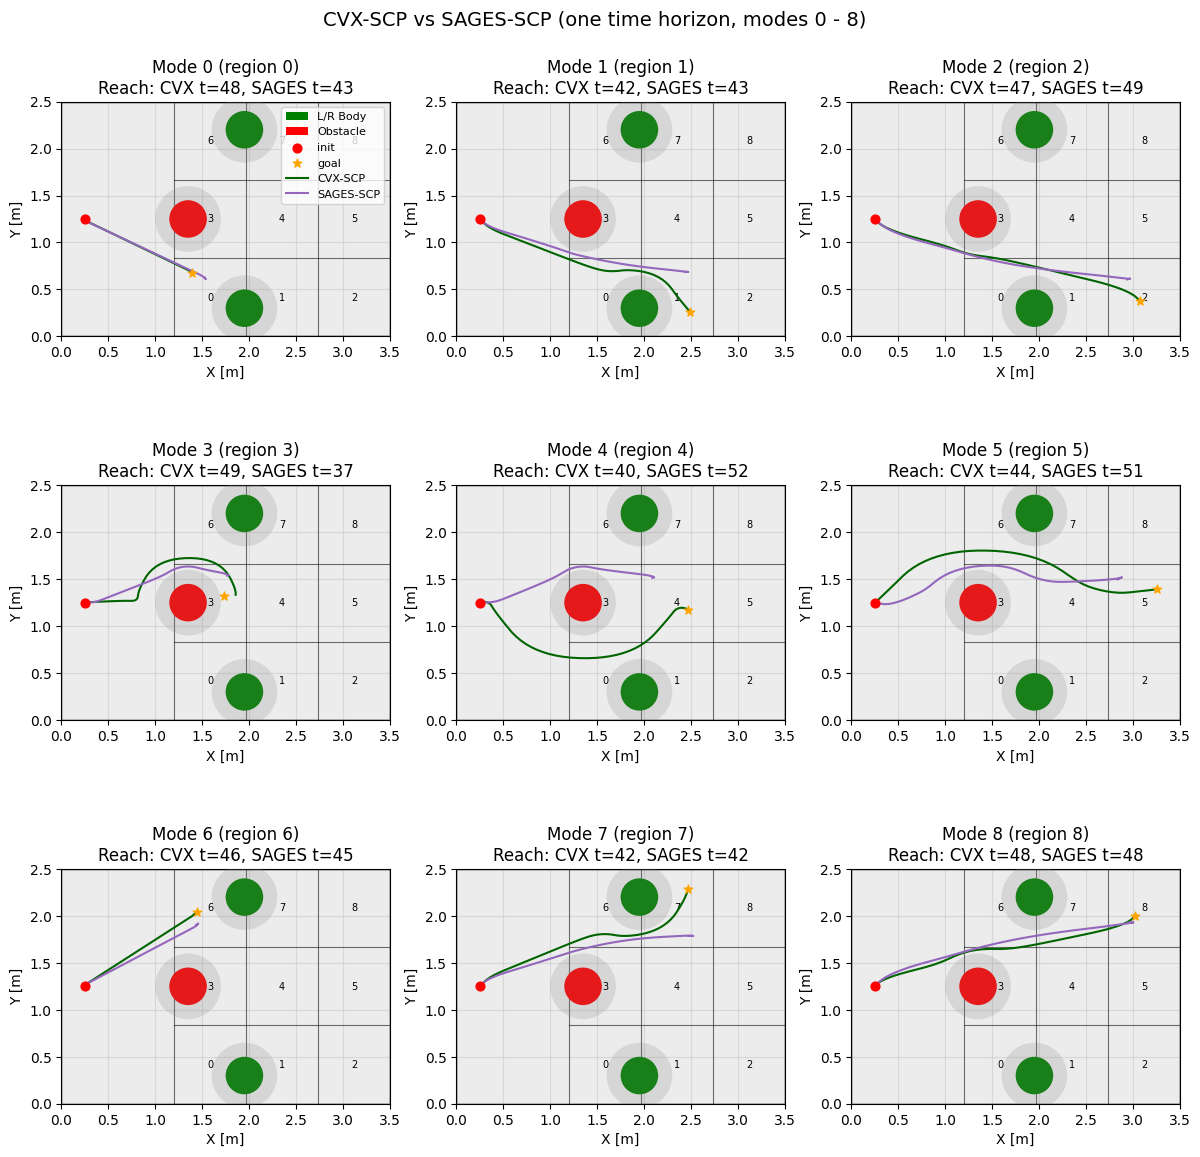

In [17]:
# Infer and solve for all behavior modes 0-8 (3x3 regions), one time horizon; plot CVX vs SAGES per mode
state_init = np.array([0.25, 1.25, 0.0, 0.0, 0.0, 0.0])
time_id = 0 # single time horizon
k_T = [60, 80, 100][time_id]
wp = None
rng = np.random.default_rng(42)
regions = build_goal_regions_3x3_xgt12(x_min=1.2, ncols=3, nrows=3)


command_mapping = load_behavior_texts(root_folder / "dataset" / "master_file.json")
data_stats = test_loader.dataset.data_stats
n_modes = 9

# Store trajectories for CVX-SCP and SAGES-SCP per mode (states = (6, k_T+1))
states_cvx_scp_list = [None] * n_modes
states_sages_scp_list = [None] * n_modes
goal_xy_list = [None] * n_modes
cvx_ok_list = [False] * n_modes

for behavior_i in range(9*time_id, 9*(time_id+1)):
    region_id = behavior_i % 9
    goal_xy = sample_goal_in_region(rng, regions[region_id])
    goal_xy_list[behavior_i%9] = goal_xy.copy()
    state_final = np.zeros(6, dtype=float)
    state_final[0:2] = goal_xy
    command_id = int(rng.integers(0, 100))
    text_command = get_behavior_text(command_mapping, behavior_i, command_id)

    # CVX then SCP
    traj_cvx, _, _, feas_cvx = ocp_no_obstacle_avoidance(ff_model, state_init, state_final, n_time_override=k_T, waypoint=wp)
    cvx_ok = (
        traj_cvx is not None
        and str(feas_cvx).strip().lower() == "optimal"
        and traj_cvx.get("states") is not None
        and traj_cvx.get("actions_G") is not None
    )
    cvx_ok_list[behavior_i%9] = cvx_ok
    if cvx_ok:
        states_ws_cvx = traj_cvx["states"]
        actions_ws_cvx = traj_cvx["actions_G"]
        traj_scp_cvx, _, _, _ = ocp_obstacle_avoidance_feasibility_ST(ff_model, states_ws_cvx, actions_ws_cvx, state_init, w_tracking=1.0)
        states_cvx_scp_list[behavior_i%9] = traj_scp_cvx["states"]

    # SAGES (DT) then SCP (v_02 model does not take goal as input; goal_i kept for tuple unpacking, goal_xy for eval/plot)
    test_sample = test_loader.dataset.getix(0)
    (states_i, actions_i, rtgs_i, ctgs_i, goal_i, timesteps_i, attention_mask_i, dt, time_sec, ix, behavior_i_t, command_id_i_t) = test_sample
    test_sample[0][0, :, :] = (torch.tensor(np.repeat(state_init[None, :], n_time_rpod, axis=0)) - data_stats["states_mean"]) / (data_stats["states_std"] + 1e-6)
    test_sample[1][0, :, :] = torch.zeros((n_time_rpod, N_ACTION))
    test_sample[2][0, :, 0] = torch.zeros((n_time_rpod,))
    test_sample[3][:, 0] = torch.zeros((n_time_rpod,))
    goal_mean = data_stats["goal_mean"]
    goal_std = data_stats["goal_std"]
    if goal_mean.dim() == 2:
        goal_mean, goal_std = goal_mean[0, :], goal_std[0, :]
    goal_norm = (torch.tensor(state_final, dtype=torch.float32) - goal_mean) / (goal_std + 1e-6)
    goal_i[0, :, :] = goal_norm.unsqueeze(0).expand(goal_i.shape[1], -1)
    test_sample = (states_i, actions_i, rtgs_i, ctgs_i, goal_i, timesteps_i, attention_mask_i, dt, time_sec, ix, behavior_i_t, command_id_i_t)

    DT_traj, _ = DT_manager.torch_model_inference_dyn(model_ctg, test_loader, test_sample, text_encoder_ctg, command_mapping, ctg_condition=True, text_command=text_command)
    states_ws_DT = np.append(DT_traj["xypsi_dyn"], (DT_traj["xypsi_dyn"][:, -1] + ff_model.B_imp @ DT_traj["dv_dyn"][:, -1]).reshape((6, 1)), axis=1)
    actions_ws_DT = DT_traj["dv_dyn"]
    traj_scp_DT, _, _, _ = ocp_obstacle_avoidance_feasibility_ST(ff_model, states_ws_DT, actions_ws_DT, state_init)
    states_sages_scp_list[behavior_i%9] = traj_scp_DT["states"]

# 9 subplots: CVX-SCP and SAGES-SCP on same canvas per mode
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i in range(n_modes):
    ax = axes[i]
    _plot_environment(ax)
    plot_9_region_grid(ax, x_min=1.2, xs=grid_xs, ys=grid_ys, annotate=True)
    gxy = goal_xy_list[i]
    # Reach time = first time (x,y) enters this mode's grid region
    region_id = i
    x_lo, x_hi, y_lo, y_hi = regions[region_id]
    t_reach_parts = []
    if states_cvx_scp_list[i] is not None:
        Sc = states_cvx_scp_list[i]
        in_region_c = ((Sc[0, :] >= x_lo) & (Sc[0, :] <= x_hi) & (Sc[1, :] >= y_lo) & (Sc[1, :] <= y_hi))
        tc = int(np.argmax(in_region_c)) if np.any(in_region_c) else (Sc.shape[1] - 1)
        t_reach_parts.append(f"CVX t={tc}")
    if states_sages_scp_list[i] is not None:
        Ss = states_sages_scp_list[i]
        in_region_s = ((Ss[0, :] >= x_lo) & (Ss[0, :] <= x_hi) & (Ss[1, :] >= y_lo) & (Ss[1, :] <= y_hi))
        ts = int(np.argmax(in_region_s)) if np.any(in_region_s) else (Ss.shape[1] - 1)
        t_reach_parts.append(f"SAGES t={ts}")
    subtitle = ", ".join(t_reach_parts) if t_reach_parts else "—"
    ax.set_title(f"Mode {9*(time_id)+i} (region {i})\nReach: {subtitle}", fontsize=12)
    ax.scatter(state_init[0], state_init[1], s=40, marker="o", c="red", label="init", zorder=5)
    ax.scatter(gxy[0], gxy[1], s=40, marker="*", c="orange", label="goal", zorder=5)
    if states_cvx_scp_list[i] is not None:
        S = states_cvx_scp_list[i]
        ax.plot(S[0, :], S[1, :], linestyle="-", color="darkgreen", linewidth=1.5, label="CVX-SCP", zorder=4)
    else:
        ax.text(0.5, 0.5, "CVX infeas.", transform=ax.transAxes, fontsize=9, ha="center")
    if states_sages_scp_list[i] is not None:
        S = states_sages_scp_list[i]
        ax.plot(S[0, :], S[1, :], linestyle="-", color="tab:purple", linewidth=1.5, label="SAGES-SCP", zorder=4)
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)
plt.suptitle(f"CVX-SCP vs SAGES-SCP (one time horizon, modes {9*(time_id)} - {9*(time_id+1)-1})", fontsize=14)
plt.tight_layout()
plt.show()


# 3D Plot for time

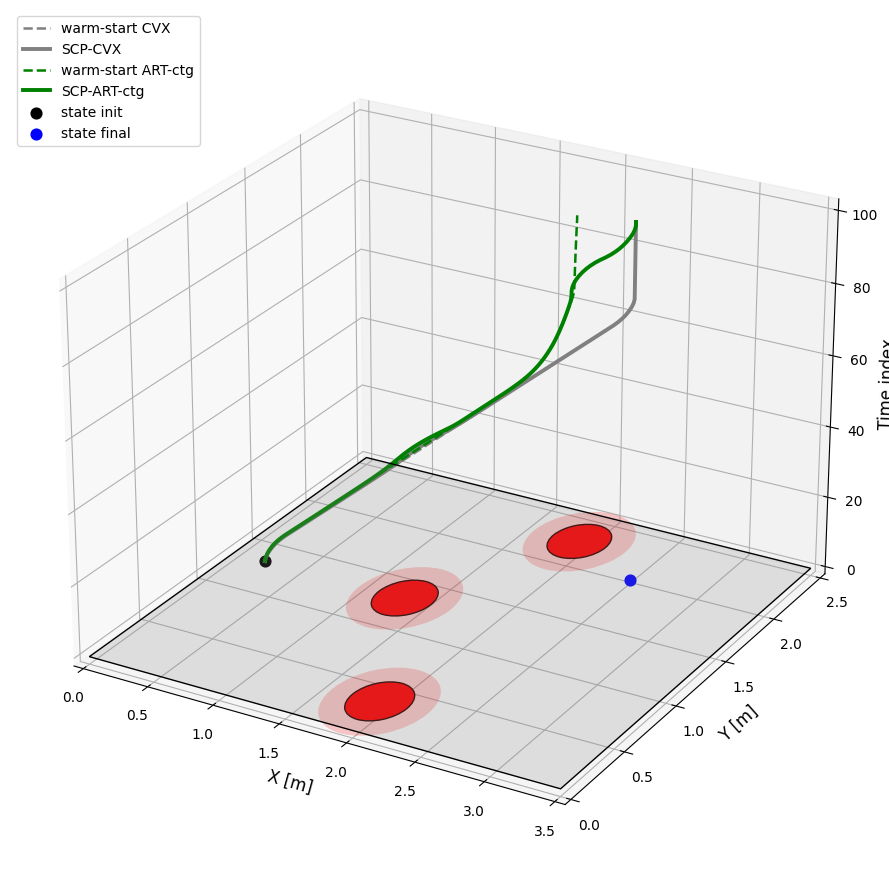

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle
from mpl_toolkits.mplot3d import art3d

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# --- time axes for each trajectory ---
T_ws_cvx   = states_ws_cvx.shape[1]
T_scp_cvx  = states_scp_full.shape[1]
T_ws_ctg   = states_ws_DT_ctg.shape[1]
T_scp_ctg  = states_scp_DT_ctg.shape[1]

t_ws_cvx   = np.arange(T_ws_cvx)
t_scp_cvx  = np.arange(T_scp_cvx)
t_ws_ctg   = np.arange(T_ws_ctg)
t_scp_ctg  = np.arange(T_scp_ctg)

# ------------------------------
#   TRAJECTORIES (3D)
# ------------------------------

# CVX warm-start (dashed grey)
ax.plot(
    states_ws_cvx[0, :], states_ws_cvx[1, :], t_ws_cvx,
    linestyle='--', color='grey', linewidth=1.8,
    label='warm-start CVX', zorder=5
)

# CVX SCP (solid grey)
ax.plot(
    states_scp_full[0, :], states_scp_full[1, :], t_scp_cvx,
    linestyle='-', color='grey', linewidth=2.8,
    label='SCP-CVX', zorder=6
)

# ART warm-start (dashed green)
ax.plot(
    states_ws_DT_ctg[0, :], states_ws_DT_ctg[1, :], t_ws_ctg,
    linestyle='--', color='green', linewidth=1.8,
    label='warm-start ART-ctg', zorder=7
)

# ART SCP (solid green)
ax.plot(
    states_scp_DT_ctg[0, :], states_scp_DT_ctg[1, :], t_scp_ctg,
    linestyle='-', color='green', linewidth=2.8,
    label='SCP-ART-ctg', zorder=8
)

# ------------------------------
#   ENVIRONMENT (projected at t=0)
# ------------------------------

# Table as a 2D patch projected into 3D at z=0
table_patch = Rectangle(
    (0, 0),
    table['xy_up'][0], table['xy_up'][1],
    fc=(0.5, 0.5, 0.5, 0.2), ec='k'
)
ax.add_patch(table_patch)
art3d.pathpatch_2d_to_3d(table_patch, z=0, zdir="z")

# Obstacles (also projected at z=0)
for n_obs in range(obs['radius'].shape[0]):
    circle_main = Circle(obs['position'][n_obs], obs['radius'][n_obs], fc='r', ec='k')
    ax.add_patch(circle_main)
    art3d.pathpatch_2d_to_3d(circle_main, z=0, zdir="z")

    circle_inf = Circle(
        obs['position'][n_obs], obs['radius'][n_obs] + robot_radius,
        fc='r', alpha=0.2
    )
    ax.add_patch(circle_inf)
    art3d.pathpatch_2d_to_3d(circle_inf, z=0, zdir="z")

# ------------------------------
# START + GOAL (put them at t=0)
# ------------------------------
ax.scatter(state_init[0], state_init[1], 0, s=60, c='black', label='state init', zorder=10)
ax.scatter(state_final[0], state_final[1], 0, s=60, c='blue',  label='state final', zorder=10)

# ------------------------------
# Formatting
# ------------------------------

ax.set_xlabel('X [m]', fontsize=12)
ax.set_ylabel('Y [m]', fontsize=12)
ax.set_zlabel('Time index', fontsize=12)

ax.set_xlim(0, table['xy_up'][0])
ax.set_ylim(0, table['xy_up'][1])

T_max = max(T_ws_cvx, T_scp_cvx, T_ws_ctg, T_scp_ctg)
ax.set_zlim(0, T_max)

ax.view_init(elev=25, azim=-60)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()
